In [1]:
# Dataset Load

import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("ecommerce_clean_data.csv")

In [3]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

In [4]:
df.head()

,OrderID,OrderDate,CustomerID,PaymentMethod,OrderStatus,CustomerName,Gender,Age,City,Region,...,Profit,ProductName,Category,CostPrice,SellingPrice,Year,Month,MonthName,YearMonth,ProfitMarginPct
0,O00001,2026-01-19,C0484,UPI,Delivered,Customer_0484,Female,31,Pune,West,...,12649.20,Mouse,Electronics,5353.0,10018.0,2026,1,January,2026-01,37.136683
1,O00001,2026-01-19,C0484,UPI,Delivered,Customer_0484,Female,31,Pune,West,...,6532.80,Shampoo,Beauty,3112.0,5568.0,2026,1,January,2026-01,41.167574
2,O00002,2026-02-14,C0450,Credit Card,Delivered,Customer_0450,Female,23,Hyderabad,South,...,3909.45,Table Lamp,Home,5905.0,10331.0,2026,2,February,2026-02,39.833613
3,O00002,2026-02-14,C0450,Credit Card,Delivered,Customer_0450,Female,23,Hyderabad,South,...,2006.80,Air Fryer,Home,3425.0,4363.0,2026,2,February,2026-02,12.776632
4,O00003,2025-11-21,C0523,Credit Card,Delivered,Customer_0523,Female,60,Delhi,North,...,4543.90,T-Shirt,Fashion,3999.0,6601.0,2025,11,November,2025-11,36.229758


In [5]:
# Hum SalesAmount se statistics samjhenge.

sales = df[
    df["OrderStatus"] == "Delivered"
]["SalesAmount"]

In [6]:
sales.head()

0    34061.20
1    15868.80
2     9814.45
3    15706.80
4    12541.90
Name: SalesAmount, dtype: float64

In [7]:
sales.count()

np.int64(10970)

In [8]:
# Mean = Sum of all values / Number of values

sales.mean()

np.float64(13975.564225159524)

In [15]:
a  = [25,35,45,55,65,1000]

b = pd.DataFrame(a)

b.mean()

0    50.0
dtype: float64

In [13]:
x  = [25,35,45,55,65,75]

y = pd.DataFrame(x)

y.mean()

0    50.0
dtype: float64

In [14]:
sales.median()

np.float64(11169.75)

In [16]:
a  = [25,35,45,55,65,1000]

b = pd.DataFrame(a)

b.median()

0    50.0
dtype: float64

In [17]:
x  = [25,35,45,55,65,75]

y = pd.DataFrame(x)

y.mean()

0    50.0
dtype: float64

In [18]:
# Mode

sales.mode()

0    900.0
Name: SalesAmount, dtype: float64

In [19]:
df["PaymentMethod"].mode()

0    UPI
Name: PaymentMethod, dtype: object

In [20]:
# Minimum & Maximum

sales.max()

np.float64(57080.0)

In [21]:
sales.min()

np.float64(239.25)

In [22]:
# Range

# Range = Maximum - Minimum

sales.max()-sales.min()

np.float64(56840.75)

In [23]:
# Variance

sales.var()

np.float64(113047797.66877817)

In [24]:
# Standard Deviation

sales.std()

np.float64(10632.393788266976)

In [25]:
# Quartiles

sales.quantile(0.25)

np.float64(5947.45)

In [26]:
sales.quantile(0.50)

np.float64(11169.75)

In [27]:
sales.quantile(0.75)

np.float64(20036.0)

In [28]:
sales.quantile([0, 0.25, 0.50, 0.75, 1])

0.00      239.25
0.25     5947.45
0.50    11169.75
0.75    20036.00
1.00    57080.00
Name: SalesAmount, dtype: float64

In [29]:
# IQR
# IQR = Q3 - Q1

Q1 = sales.quantile(0.25)
Q3 = sales.quantile(0.75)

IQR = Q3 - Q1

IQR

np.float64(14088.55)

In [31]:
# Outlier Detection Using IQR

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

lower_limit,upper_limit

(np.float64(-15185.374999999996), np.float64(41168.825))

In [32]:
# Identify Outliers

outliers = sales[
    (sales < lower_limit) |
    (sales > upper_limit)
]

In [33]:
outliers.count()

np.int64(245)

In [34]:
# Outlier Percentage

outlier_percentage = (
    len(outliers) / len(sales)
) * 100

outlier_percentage

2.2333637192342755

In [35]:
# Five Number Summary

five_number = {
    "Minimum": sales.min(),
    "Q1": sales.quantile(0.25),
    "Median": sales.median(),
    "Q3": sales.quantile(0.75),
    "Maximum": sales.max()
}

five_number

{'Minimum': np.float64(239.25),
 'Q1': np.float64(5947.45),
 'Median': np.float64(11169.75),
 'Q3': np.float64(20036.0),
 'Maximum': np.float64(57080.0)}

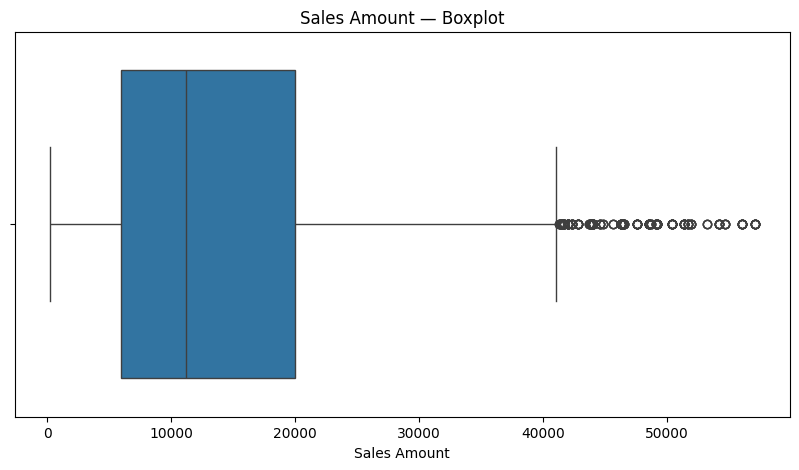

In [40]:
# Boxplot

import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(x=sales)

plt.title("Sales Amount — Boxplot")
plt.xlabel("Sales Amount")

plt.show()

In [41]:
# Correlation

numeric_cols = [
    "Age",
    "Quantity",
    "UnitPrice",
    "DiscountPct",
    "SalesAmount",
    "Profit"
]

In [42]:
correlation = df[numeric_cols].corr()

correlation

,Age,Quantity,UnitPrice,DiscountPct,SalesAmount,Profit
Age,1.000000,0.005574,-0.001661,-0.000709,0.000313,0.003488
Quantity,0.005574,1.000000,-0.000415,0.002037,0.588638,0.438354
UnitPrice,-0.001661,-0.000415,1.000000,-0.003870,0.727013,0.699047
DiscountPct,-0.000709,0.002037,-0.003870,1.000000,-0.111380,-0.235076
SalesAmount,0.000313,0.588638,0.727013,-0.111380,1.000000,0.907850
Profit,0.003488,0.438354,0.699047,-0.235076,0.907850,1.000000


In [43]:
# Discount vs Profit Correlation

df["DiscountPct"].corr(
    df["Profit"]
)

np.float64(-0.23507564895379612)

In [44]:
# Quantity vs Sales Correlation

df["Quantity"].corr(
    df["SalesAmount"]
)

np.float64(0.5886376290793074)

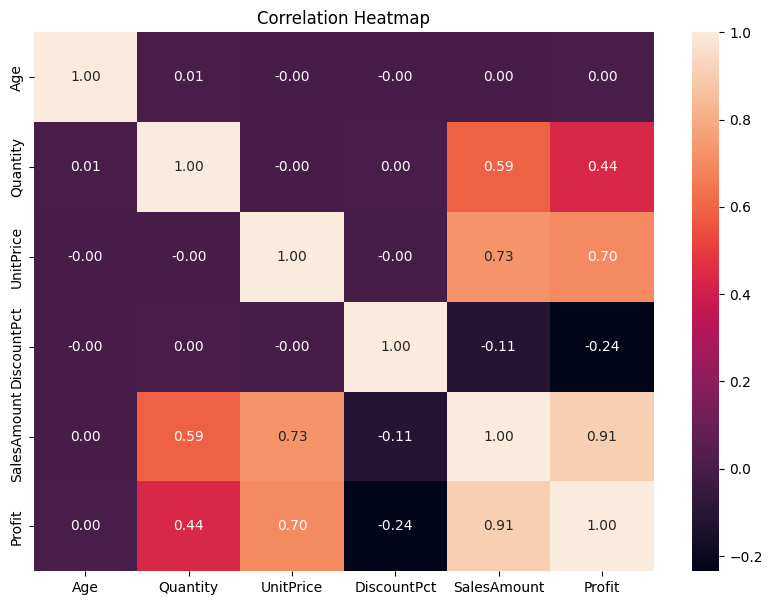

In [45]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [46]:
# Statistics Summary
statistics_summary = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Minimum",
        "Maximum",
        "Variance",
        "Standard Deviation",
        "Q1",
        "Q3",
        "IQR"
    ],
    "Value": [
        sales.mean(),
        sales.median(),
        sales.min(),
        sales.max(),
        sales.var(),
        sales.std(),
        Q1,
        Q3,
        IQR
    ]
})

statistics_summary

,Metric,Value
0,Mean,1.397556e+04
1,Median,1.116975e+04
2,Minimum,2.392500e+02
3,Maximum,5.708000e+04
4,Variance,1.130478e+08
5,Standard Deviation,1.063239e+04
6,Q1,5.947450e+03
7,Q3,2.003600e+04
8,IQR,1.408855e+04
